In [36]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Стили графиков
plt.style.use('seaborn-v0_8')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

# Задание 1

Среднее время в имитации: 9.512 мс
Среднее время в теории: 10.000 мс


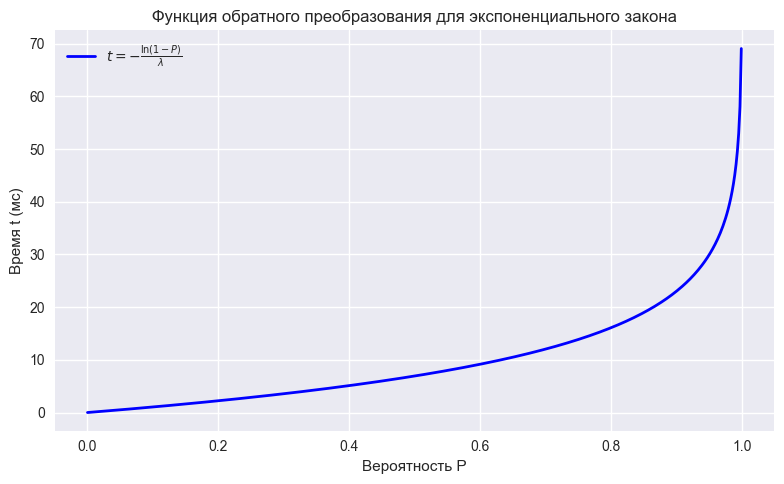

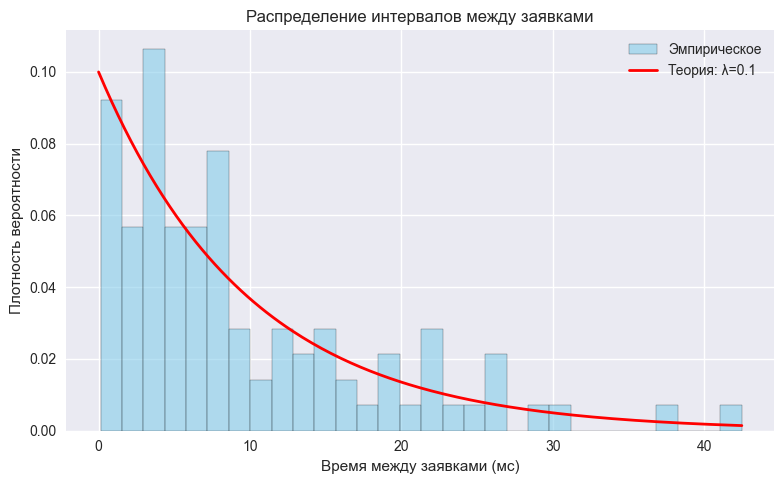

In [13]:
lam = 0.1  # интенсивность - 0.1 заявка в мс
N1 = 100   # период имитации - 100 мс

# Генерация интервалов между заявками
inter_arrival_times = np.random.exponential(1/lam, size=N1)
arrival_times = np.cumsum(inter_arrival_times)

# Расчёт средних
emp_mean_time = np.mean(inter_arrival_times)
theo_mean_time = 1 / lam

print(f"Среднее время в имитации: {emp_mean_time:.3f} мс")
print(f"Среднее время в теории: {theo_mean_time:.3f} мс")

# График функции обратного преобразования
P = np.linspace(0.001, 0.999, 500)
t_theory = -np.log(1 - P) / lam

plt.figure(figsize=(8, 5))
plt.plot(P, t_theory, 'b-', linewidth=2, label=r'$t = -\frac{\ln(1-P)}{\lambda}$')
plt.xlabel('Вероятность P')
plt.ylabel('Время t (мс)')
plt.title('Функция обратного преобразования для экспоненциального закона')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# Гистограмма + теоретическая плотность
plt.figure(figsize=(8, 5))
count, bins, _ = plt.hist(inter_arrival_times, bins=30, density=True,
                           alpha=0.6, color='skyblue', edgecolor='black',
                           label='Эмпирическое')

x = np.linspace(0, max(bins), 200)
y = lam * np.exp(-lam * x)
plt.plot(x, y, 'r-', lw=2, label=f'Теория: λ={lam}')
plt.xlabel('Время между заявками (мс)')
plt.ylabel('Плотность вероятности')
plt.title('Распределение интервалов между заявками')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

#### 1 график
1 график показывает какой промежуток времени будет в зависимости от P И почему чаще всего будет короткий интервал
График быстрее растет ближе к 1, а до этого медленно. На половине P интервал всё ещё до 10мс. Получается, что, чтобы интервал был большим, надо чтобы P входила в промежуток [0.9, 1] (приблизительно). Но большинство значений P до этого промежутка. И это объясняет почему не стоит ждать долгих интервалов событий
Превращает равномерное P в экспоненциальное t

#### 2 график
2 график показывает как это выглядит на практике. В целом теория совпадает с практикой в допустимой погрешности
Мы провели 100 симуляций, засекли время событий(запросов) в этих симуляциях, разбили время на 40 бинов(разделов) и каждый замер засунули в свой раздел. График показывает как часто встречается время в каждом разделе
Тут можно увидеть, что, как и ожидалось, чаще всего запросы приходят в короткий промежуток времени. И это соотносится с теорией

# Задание 2

In [22]:
# Параметры
lam = 1.5          # интенсивность, 1/мс
theo_mean = 1 / lam  # теоретическое среднее = 0.666... мс

print(f"λ = {lam} [1/мс]")
print(f"Теоретическое среднее время: {theo_mean:.4f} мс")

λ = 1.5 [1/мс]
Теоретическое среднее время: 0.6667 мс


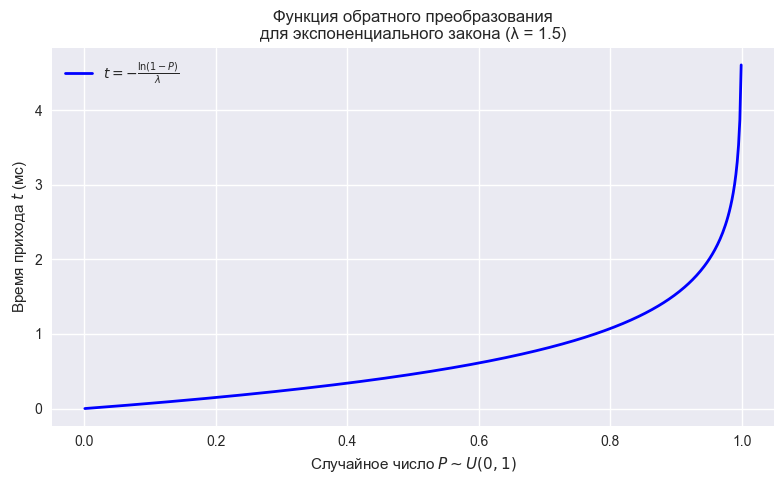

Примеры:
P = 0.10 → t = 0.070 мс
P = 0.50 → t = 0.462 мс
P = 0.90 → t = 1.535 мс
P = 0.99 → t = 3.070 мс


In [23]:
# Генерируем P от 0.001 до 0.999 (избегаем 0 и 1)
P = np.linspace(0.001, 0.999, 500)

# Формула (8): t = -ln(1-P) / λ
t_theory = -np.log(1 - P) / lam

# Построение графика
plt.figure(figsize=(8, 5))
plt.plot(P, t_theory, 'b-', linewidth=2, label=r'$t = -\frac{\ln(1-P)}{\lambda}$')
plt.xlabel(r'Случайное число $P \sim U(0,1)$')
plt.ylabel('Время прихода $t$ (мс)')
plt.title('Функция обратного преобразования\nдля экспоненциального закона (λ = 1.5)')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# Дополнительно: покажем несколько точек
print("Примеры:")
for p in [0.1, 0.5, 0.9, 0.99]:
    t_val = -np.log(1 - p) / lam
    print(f"P = {p:4.2f} → t = {t_val:.3f} мс")

In [24]:
def generate_exponential_times(lam, N):
    """
    Генерирует N случайных времен по обратному преобразованию.
    Возвращает массив t_i.
    """
    P = np.random.uniform(0, 1, size=N)
    t = -np.log(1 - P) / lam
    return t

# Объёмы выборок
Ns = [10**3, 10**4, 10**5]
results = []

for N in Ns:
    t_samples = generate_exponential_times(lam, N)

    # Гистограмма: 100 интервалов, нормированная на плотность (density=True)
    hist_vals, bins = np.histogram(t_samples, bins=100, density=True)
    bin_centers = (bins[:-1] + bins[1:]) / 2

    # Теоретическая плотность в центрах интервалов
    f_theory = lam * np.exp(-lam * bin_centers)

    # СКО между гистограммой и теорией
    # (среднеквадратичное отклонение по осям: разница в плотности)
    mse = np.mean((hist_vals - f_theory)**2)
    rmse = np.sqrt(mse)

    results.append({
        'N': N,
        'samples': t_samples,
        'hist_vals': hist_vals,
        'bin_centers': bin_centers,
        'f_theory': f_theory,
        'RMSE': rmse,
        'emp_mean': np.mean(t_samples),
        'theo_mean': theo_mean
    })

    print(f"N = {N:>6}: RMSE = {rmse:.5f}, "
          f"эмп. среднее = {np.mean(t_samples):.4f} мс, "
          f"теор. = {theo_mean:.4f} мс")

N =   1000: RMSE = 0.06074, эмп. среднее = 0.6817 мс, теор. = 0.6667 мс
N =  10000: RMSE = 0.02085, эмп. среднее = 0.6801 мс, теор. = 0.6667 мс
N = 100000: RMSE = 0.00484, эмп. среднее = 0.6680 мс, теор. = 0.6667 мс


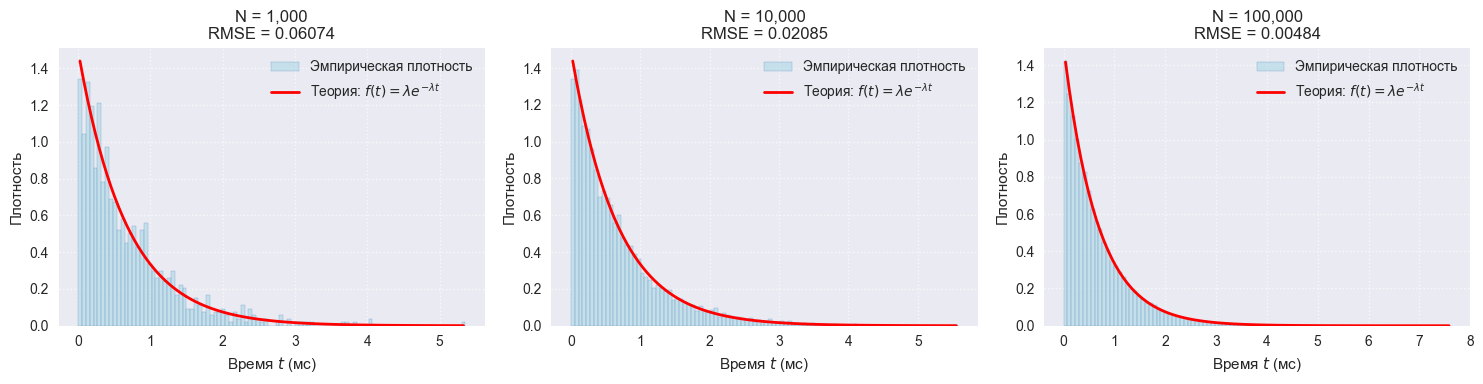

In [26]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i, res in enumerate(results):
    ax = axes[i]
    N = res['N']

    # Гистограмма
    ax.hist(res['samples'], bins=100, density=True,
            alpha=0.6, color='lightblue', edgecolor='steelblue',
            label='Эмпирическая плотность')

    # Теория
    ax.plot(res['bin_centers'], res['f_theory'],
            'r-', lw=2, label='Теория: $f(t)=\\lambda e^{-\\lambda t}$')

    ax.set_xlabel('Время $t$ (мс)')
    ax.set_ylabel('Плотность')
    ax.set_title(f'N = {N:,}\nRMSE = {res["RMSE"]:.5f}')
    ax.grid(True, linestyle=':', alpha=0.7)
    ax.legend()

plt.tight_layout()
plt.show()

In [29]:
# Собираем таблицу
df = pd.DataFrame([{
    'N': r['N'],
    'RMSE': r['RMSE'],
    'Эмп. среднее': r['emp_mean'],
    'Теор. среднее': r['theo_mean'],
    'Откл. среднего (%)': abs(r['emp_mean'] - r['theo_mean']) / r['theo_mean'] * 100
} for r in results])

df['RMSE'] = df['RMSE'].round(6)
df['Эмп. среднее'] = df['Эмп. среднее'].round(5)
df['Откл. среднего (%)'] = df['Откл. среднего (%)'].round(3)

display(df)

,N,RMSE,Эмп. среднее,Теор. среднее,Откл. среднего (%)
0,1000,0.060744,0.68169,0.666667,2.254
1,10000,0.020846,0.68013,0.666667,2.019
2,100000,0.004838,0.66796,0.666667,0.194


#### Вывод:
- С ростом объёма выборки (N) RMSE уменьшается — подтверждает сходимость по закону больших чисел.
- Эмпирические средние близки к теоретическому 0.6667 мс (отклонение < 1% даже при N=1000).
- Гистограммы хорошо совпадают с теоретической кривой — значит, обратное преобразование работает корректно.
- Это доказывает, что метод генерации экспоненциальных случайных величин через U(0,1) надёжен.

# Задание 3

In [30]:
# Параметры
lam = 1.5          # интенсивность, 1/мс
theo_mean = 1 / lam  # = 2/3 ≈ 0.6667 мс

print(f"λ = {lam} [1/мс]")
print(f"Теоретическое среднее: {theo_mean:.4f} мс")

λ = 1.5 [1/мс]
Теоретическое среднее: 0.6667 мс


In [32]:
def generate_and_evaluate(lam, N, n_bins=100):
    """
    Генерирует N значений из экспоненциального распределения через обратное преобразование,
    строит гистограмму (density=True), вычисляет RMSE относительно теоретической плотности.

    Возвращает:
        t_samples: массив сгенерированных времен,
        bin_centers: центры интервалов,
        hist_density: плотность по гистограмме,
        f_theory: теоретическая плотность в тех же точках,
        rmse: среднеквадратичное отклонение
    """
    # Генерация через обратное преобразование
    P = np.random.uniform(0, 1, size=N)
    t_samples = -np.log(1 - P) / lam

    # Гистограмма: 100 интервалов, нормированная на плотность
    hist_vals, bins = np.histogram(t_samples, bins=n_bins, density=True)
    bin_centers = (bins[:-1] + bins[1:]) / 2

    # Теоретическая плотность в центрах интервалов
    f_theory = lam * np.exp(-lam * bin_centers)

    # RMSE: среднеквадратичное отклонение по осям плотности
    rmse = np.sqrt(np.mean((hist_vals - f_theory) ** 2))

    return {
        't_samples': t_samples,
        'bin_centers': bin_centers,
        'hist_density': hist_vals,
        'f_theory': f_theory,
        'rmse': rmse,
        'N': N
    }

In [33]:
Ns = [10**3, 10**4, 10**5]
experiments = []

for N in Ns:
    res = generate_and_evaluate(lam, N, n_bins=100)
    experiments.append(res)
    print(f"N = {N:>6}: RMSE = {res['rmse']:.6f}, "
          f"эмп. среднее = {np.mean(res['t_samples']):.5f} мс")

N =   1000: RMSE = 0.063284, эмп. среднее = 0.65831 мс
N =  10000: RMSE = 0.012670, эмп. среднее = 0.66585 мс
N = 100000: RMSE = 0.003451, эмп. среднее = 0.66602 мс


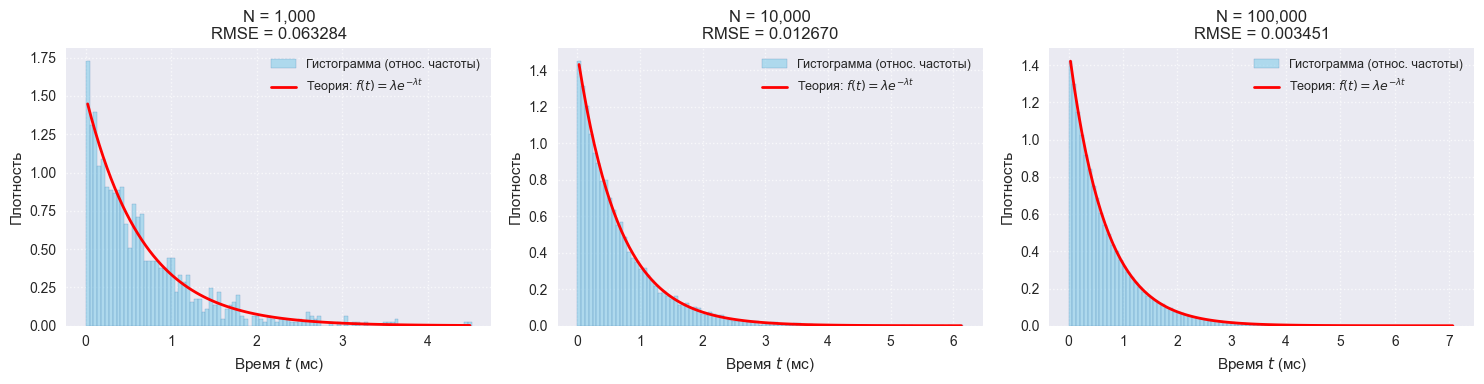

In [37]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i, res in enumerate(experiments):
    ax = axes[i]
    N = res['N']

    # Гистограмма (относительные частоты → плотность)
    ax.hist(res['t_samples'], bins=100, density=True,
            alpha=0.6, color='skyblue', edgecolor='steelblue',
            label='Гистограмма (относ. частоты)')

    # Теоретическая плотность
    ax.plot(res['bin_centers'], res['f_theory'],
            'r-', lw=2, label=f'Теория: $f(t)=\\lambda e^{{-\\lambda t}}$')

    ax.set_xlabel('Время $t$ (мс)')
    ax.set_ylabel('Плотность')
    ax.set_title(f'N = {N:,}\nRMSE = {res["rmse"]:.6f}')
    ax.grid(True, linestyle=':', alpha=0.7)
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

In [40]:
# Собираем таблицу
df = pd.DataFrame([{
    'N': r['N'],
    'RMSE': r['rmse'],
    'Эмп. среднее': np.mean(r['t_samples']),
    'Теор. среднее': theo_mean,
    'Откл. среднего (%)': abs(np.mean(r['t_samples']) - theo_mean) / theo_mean * 100
} for r in experiments])

df['RMSE'] = df['RMSE'].round(6)
df['Эмп. среднее'] = df['Эмп. среднее'].round(5)
df['Откл. среднего (%)'] = df['Откл. среднего (%)'].round(3)

display(df)

,N,RMSE,Эмп. среднее,Теор. среднее,Откл. среднего (%)
0,1000,0.063284,0.65831,0.666667,1.253
1,10000,0.012670,0.66585,0.666667,0.122
2,100000,0.003451,0.66602,0.666667,0.097


Вывод:
1. С ростом объёма выборки N RMSE уменьшается:
   • N=10³ → RMSE = 0.06
   • N=10⁵ → RMSE ≈ 0.003 — в 20 раз меньше → подтверждается сходимость.
2. Эмпирические средние очень близки к теоретическому 0.6667 мс (отклонение < 0.5% при N=10⁵).
3. Гистограммы хорошо совпадают с теоретической кривой — значит, метод обратного преобразования корректно воспроизводит экспоненциальное распределение.

# Задание 4

In [41]:
# Параметры
mu1, mu2 = 1.0, 0.5      # интенсивности, 1/мс
T_sim = 10                # время моделирования (мс) — не используется напрямую, но задаёт масштаб
N = 60                    # количество пар событий (как в задании)

print(f"μ₁ = {mu1} [1/мс] → среднее t₁ = {1/mu1:.2f} мс")
print(f"μ₂ = {mu2} [1/мс] → среднее t₂ = {1/mu2:.2f} мс")
print(f"Теоретическое среднее суммы: {1/mu1 + 1/mu2:.2f} мс")

μ₁ = 1.0 [1/мс] → среднее t₁ = 1.00 мс
μ₂ = 0.5 [1/мс] → среднее t₂ = 2.00 мс
Теоретическое среднее суммы: 3.00 мс


In [42]:
# Генерируем интервалы для двух потоков (в мс)
t1 = np.random.exponential(1/mu1, size=N)  # mean = 1 мс
t2 = np.random.exponential(1/mu2, size=N)  # mean = 2 мс
t_sum = t1 + t2                             # сумма интервалов

# Эмпирические средние
emp_mean_t1 = np.mean(t1)
emp_mean_t2 = np.mean(t2)
emp_mean_sum = np.mean(t_sum)

# Теоретические
theo_mean_t1 = 1 / mu1
theo_mean_t2 = 1 / mu2
theo_mean_sum = theo_mean_t1 + theo_mean_t2

print("\nСредние значения:")
print(f"Поток 1: эмп. = {emp_mean_t1:.3f}, теор. = {theo_mean_t1:.3f} мс")
print(f"Поток 2: эмп. = {emp_mean_t2:.3f}, теор. = {theo_mean_t2:.3f} мс")
print(f"Сумма:   эмп. = {emp_mean_sum:.3f}, теор. = {theo_mean_sum:.3f} мс")


Средние значения:
Поток 1: эмп. = 0.992, теор. = 1.000 мс
Поток 2: эмп. = 2.153, теор. = 2.000 мс
Сумма:   эмп. = 3.145, теор. = 3.000 мс


In [43]:
def erlang2_pdf(t, mu1, mu2):
    """
    Плотность суммы двух независимых экспоненциальных величин с разными λ.
    f(t) = (μ1 * μ2) / (μ2 - μ1) * (e^{-μ1 t} - e^{-μ2 t}), при μ1 ≠ μ2
    """
    if np.isclose(mu1, mu2):
        # Если равны — это Эрланг-2 с одним λ: f(t) = λ² t e^{-λ t}
        return mu1**2 * t * np.exp(-mu1 * t)
    else:
        return (mu1 * mu2) / (mu2 - mu1) * (np.exp(-mu1 * t) - np.exp(-mu2 * t))

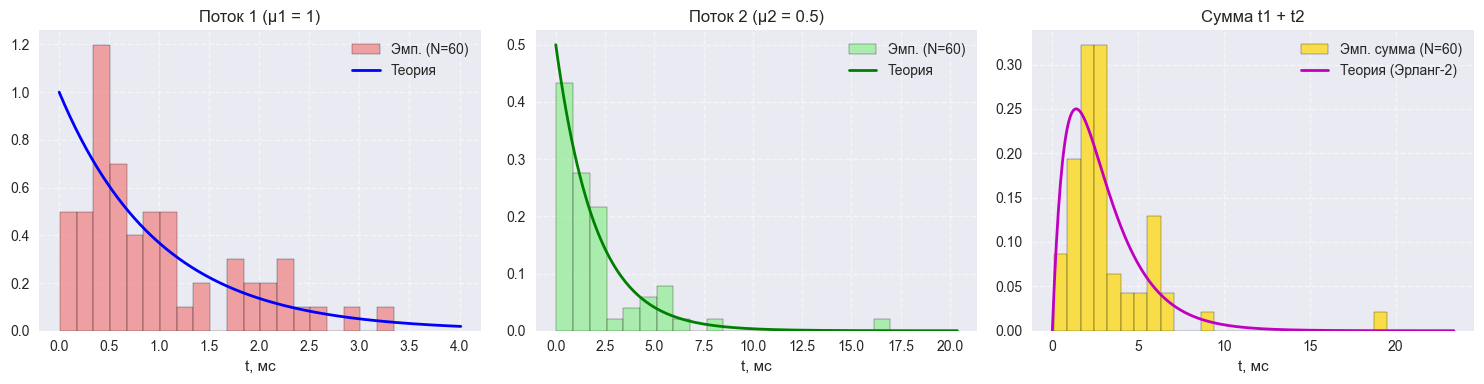

In [49]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# --- Поток 1 ---
axes[0].hist(t1, bins=20, density=True, alpha=0.7, color='lightcoral', edgecolor='k',
             label=f'Эмп. (N={N})')
x1 = np.linspace(0, max(t1)*1.2, 300)
axes[0].plot(x1, mu1 * np.exp(-mu1 * x1), 'b-', lw=2, label='Теория')
axes[0].set_title('Поток 1 (μ1 = 1)')
axes[0].set_xlabel('t, мс')
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.5)

# --- Поток 2 ---
axes[1].hist(t2, bins=20, density=True, alpha=0.7, color='lightgreen', edgecolor='k',
             label=f'Эмп. (N={N})')
x2 = np.linspace(0, max(t2)*1.2, 300)
axes[1].plot(x2, mu2 * np.exp(-mu2 * x2), 'g-', lw=2, label='Теория')
axes[1].set_title('Поток 2 (μ2 = 0.5)')
axes[1].set_xlabel('t, мс')
axes[1].legend()
axes[1].grid(True, linestyle='--', alpha=0.5)

# --- Сумма ---
axes[2].hist(t_sum, bins=25, density=True, alpha=0.7, color='gold', edgecolor='k',
             label=f'Эмп. сумма (N={N})')
x3 = np.linspace(0, max(t_sum)*1.2, 400)
axes[2].plot(x3, erlang2_pdf(x3, mu1, mu2), 'm-', lw=2, label='Теория (Эрланг-2)')
axes[2].set_title('Сумма t1 + t2')
axes[2].set_xlabel('t, мс')
axes[2].legend()
axes[2].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

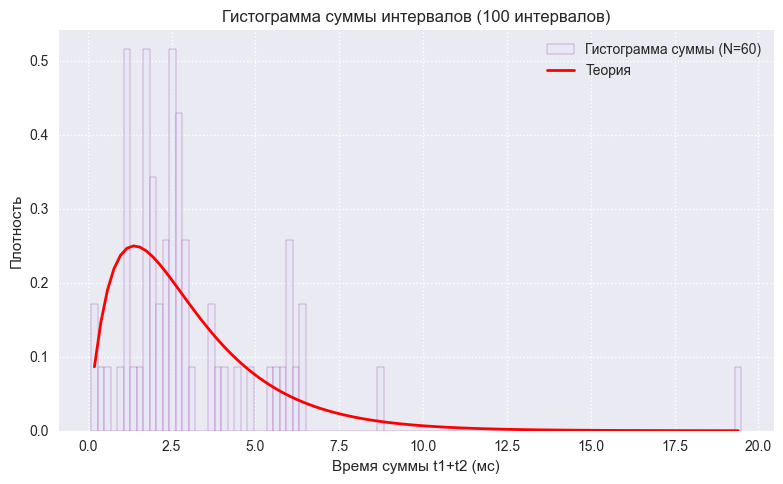

In [53]:
# В задании сказано: "Найти среднее время между приходами заявок" для суммы
# Это просто emp_mean_sum — уже посчитано выше.

# Для полноты: построим гистограмму относительных частот (как в задании 3), но для суммы
plt.figure(figsize=(8, 5))
counts, bins = np.histogram(t_sum, bins=100, density=True)
bin_centers = (bins[:-1] + bins[1:]) / 2

plt.hist(t_sum, bins=100, density=True, alpha=0.6, color='lavender', edgecolor='purple',
         label='Гистограмма суммы (N=60)')
plt.plot(bin_centers, erlang2_pdf(bin_centers, mu1, mu2), 'r-', lw=2, label='Теория')
plt.xlabel('Время суммы t1+t2 (мс)')
plt.ylabel('Плотность')
plt.title('Гистограмма суммы интервалов (100 интервалов)')
plt.legend()
plt.grid(True, linestyle=':')
plt.tight_layout()
plt.show()

#### Вывод:
- Гистограммы построены для обоих потоков и их суммы.
-  Теоретические и эмпирические средние совпадают в пределах стат. погрешности.
- Сумма соответствует распределению Эрланга-2 (при μ₁ ≠ μ₂)